In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)
df = pd.DataFrame({
    'income': np.random.exponential(50000, 200),
    'age':    np.random.randint(18, 60, 200),
    'score':  np.random.randint(40, 100, 200),
    'gender': np.random.choice(['M', 'F'], 200),
    'city':   np.random.choice(['Lagos', 'Abuja', 'Kano'], 200),
    'churned':np.random.choice([0, 1], 200)
})

df

,income,age,score,gender,city,churned
0,23463.404499,41,90,M,Kano,0
1,150506.071546,28,82,M,Abuja,0
2,65837.284677,25,76,M,Kano,1
3,45647.127689,53,51,M,Abuja,1
4,8481.243523,55,42,F,Kano,1
...,...,...,...,...,...,...
195,21478.380791,41,45,F,Abuja,1
196,64723.271486,29,97,M,Kano,0
197,113704.867455,52,83,F,Kano,1
198,109056.628470,50,84,M,Lagos,0


In [3]:
# add income log  to the table

df['income_log'] = np.log1p(df['income'])

df

,income,age,score,gender,city,churned,income_log
0,23463.404499,41,90,M,Kano,0,10.063240
1,150506.071546,28,82,M,Abuja,0,11.921765
2,65837.284677,25,76,M,Kano,1,11.094957
3,45647.127689,53,51,M,Abuja,1,10.728718
4,8481.243523,55,42,F,Kano,1,9.045730
...,...,...,...,...,...,...,...
195,21478.380791,41,45,F,Abuja,1,9.974849
196,64723.271486,29,97,M,Kano,0,11.077892
197,113704.867455,52,83,F,Kano,1,11.641370
198,109056.628470,50,84,M,Lagos,0,11.599632


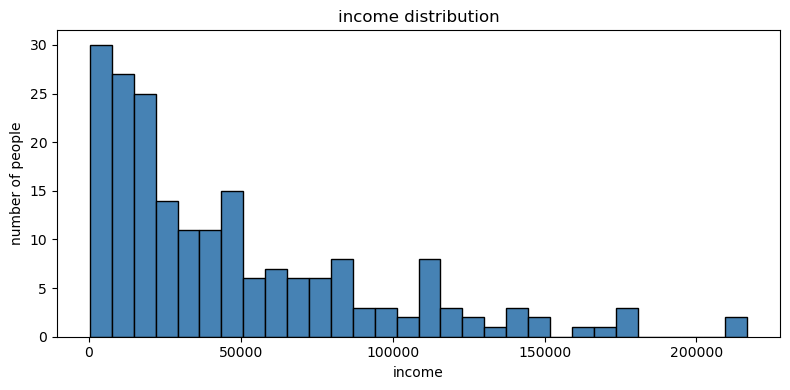

In [4]:
# A histogram cuts your data into buckets and counts how many
# values fall in each bucket — it shows you the SHAPE of your data

plt.figure(figsize = (8, 4))
plt.hist(df['income'], bins = 30, edgecolor = 'black', color = 'steelblue',)
plt.title('income distribution')
plt.xlabel('income')
plt.ylabel('number of people')
plt.tight_layout()
plt.show()

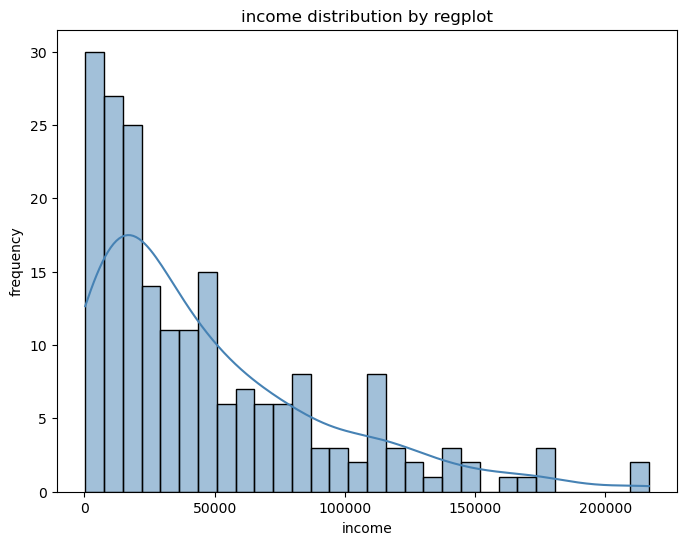

In [5]:
# The seaborn version adds a smooth KDE curve on top
# KDE = Kernel Density Estimate — a smoothed version of the histogram

plt.figure(figsize = (8, 6))
sns.histplot(df['income'], bins = 30, kde = True, color = 'steelblue')
plt.title('income distribution by regplot')
plt.xlabel('income')
plt.ylabel('frequency')
plt.show()

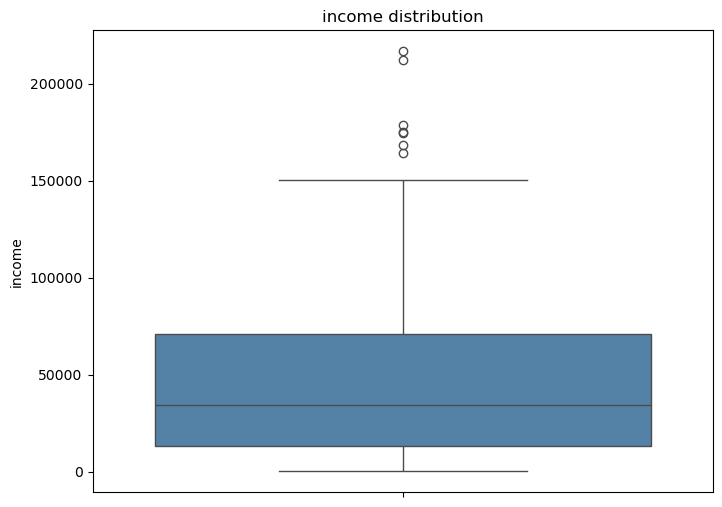

In [6]:
# Simple boxplot of one variable

plt.figure(figsize = (8, 6))
sns.boxplot(df['income'], color = 'steelblue')
plt.title('income distribution')
plt.ylabel('income')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_9928\617297076.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'city', y = 'income', palette = 'husl')


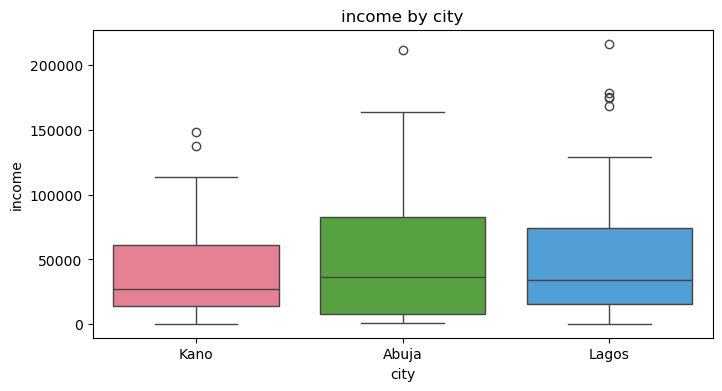

In [8]:
# More useful — compare distributions across categories

plt.figure(figsize = (8, 4))
sns.boxplot(data = df, x = 'city', y = 'income', palette = 'husl')
plt.title('income by city')
plt.xlabel('city')
plt.ylabel('income')
plt.show()

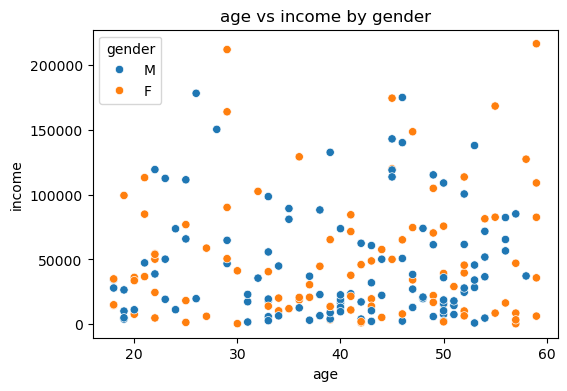

In [17]:
# A scatterplot puts two numerical variables on x and y axes

plt.figure(figsize = (6, 4))
sns.scatterplot(data = df, x = 'age', y = 'income', hue = 'gender', color = 'steelblue')
plt.title('age vs income by gender')
plt.xlabel('age')
plt.ylabel('income')
plt.show()

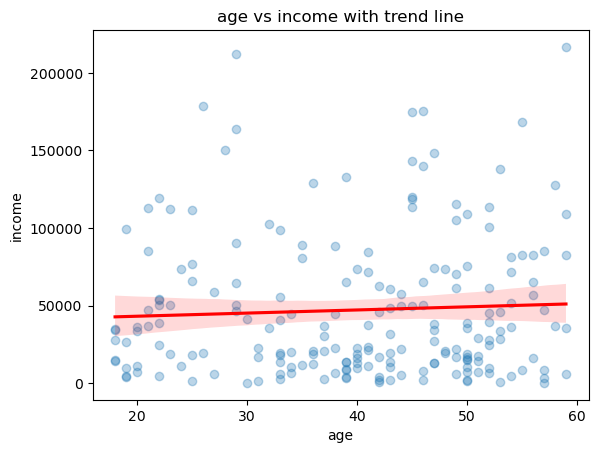

In [8]:
sns.regplot(data = df, x = 'age', y = 'income', scatter_kws = {'alpha': 0.3}, line_kws = {'color': 'red'})
plt.title('age vs income with trend line')
plt.show()

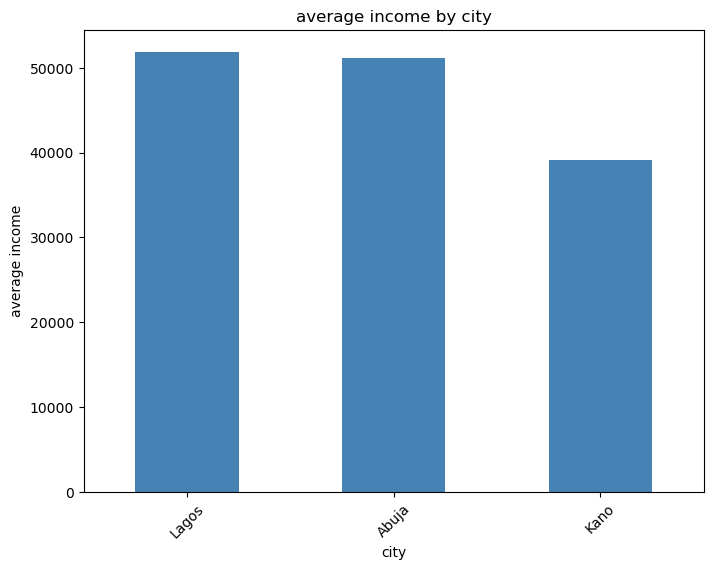

In [18]:
# Bar charts compare a numerical value across categories

city_avg = df.groupby('city')['income'].mean().round(2).sort_values(ascending = False)

plt.figure(figsize = (8, 6))
city_avg.plot(kind = 'bar', color = 'steelblue')
plt.title('average income by city')
plt.xlabel('city')
plt.ylabel('average income')
plt.xticks(rotation = 45)
plt.show()

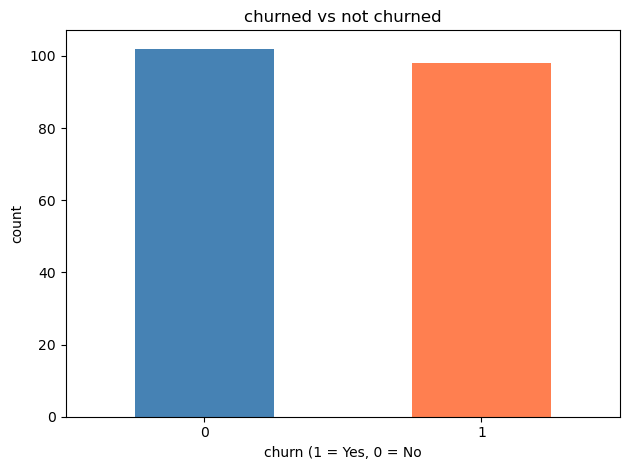

In [10]:
# Count bar chart — how many people in each category

df['churned'].value_counts().plot(kind = 'bar', color = ['steelblue', 'coral'])
plt.title('churned vs not churned')
plt.xlabel('churn (1 = Yes, 0 = No')
plt.ylabel('count')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

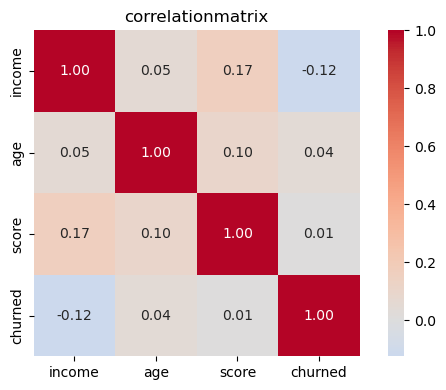

In [11]:
# A heatmap shows correlation between every pair of numerical columns

plt.figure(figsize = (6, 4))
sns.heatmap(
    df.select_dtypes('number').corr(),
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    center = 0,
    square = True
)
plt.title('correlationmatrix')
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_9928\4000613286.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'city', y = 'income', palette = 'husl', ax = axes[1, 0])


Text(0, 0.5, 'income')

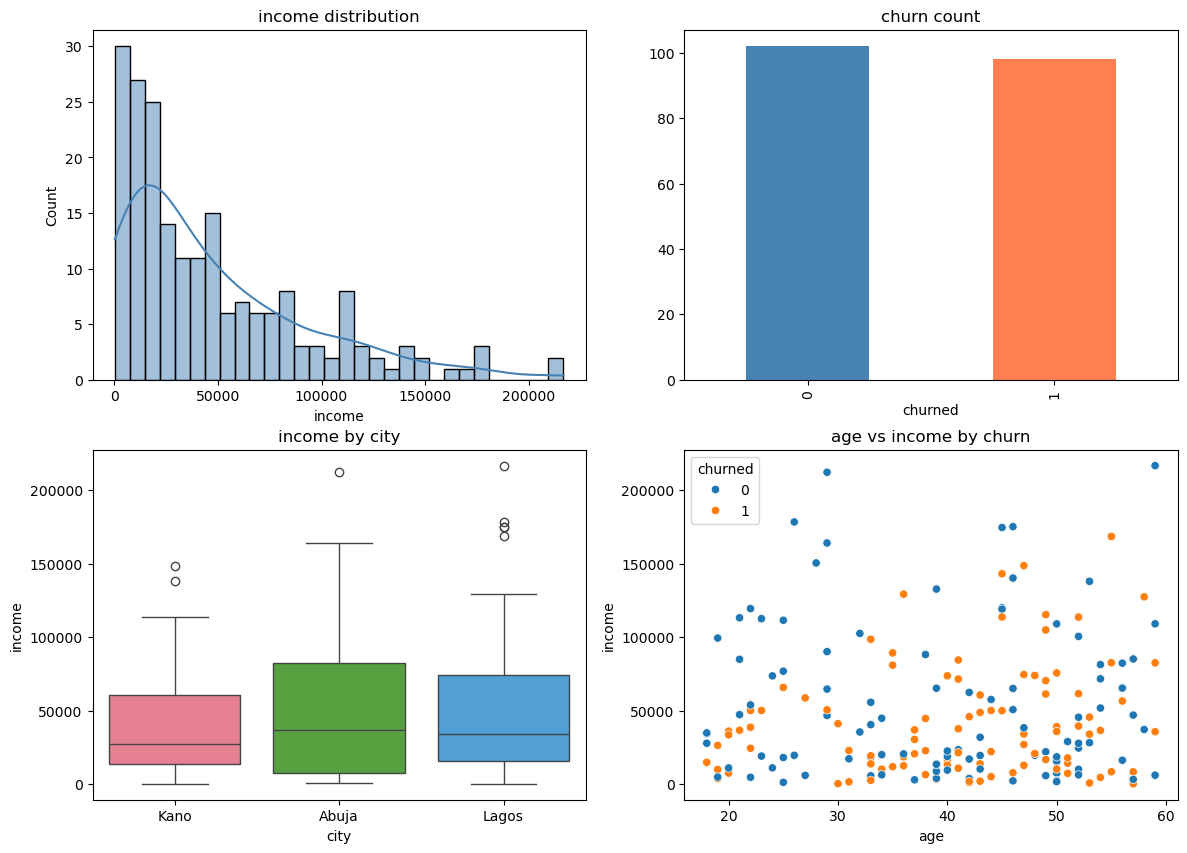

In [20]:
# Subplots — Multiple Charts in One Figure

fig, axes = plt.subplots(2, 2, figsize = (14, 10))

# Top left — axes[0, 0]
sns.histplot(df['income'], bins = 30, kde = 'True', color = 'steelblue', ax = axes[0, 0])
axes[0,0].set_title('income distribution')
axes[0,0].set_xlabel('income')


# Top right — axes[0, 1]
df['churned'].value_counts().plot(kind = 'bar', ax = axes[0, 1], color = ['steelblue', 'coral'])
axes[0, 1].set_title('churn count')
axes[0, 1].set_xlabel('churned')

# Bottom left — axes[1, 0]
sns.boxplot(data = df, x = 'city', y = 'income', palette = 'husl', ax = axes[1, 0])
axes[1,0].set_title('income by city')



# Bottom right — axes[1, 1]
sns.scatterplot(data = df, x = 'age', y = 'income', hue = 'churned', ax = axes[1,1])
axes[1,1].set_title('age vs income by churn')
axes[1,1].set_xlabel('age')
axes[1,1].set_ylabel('income')

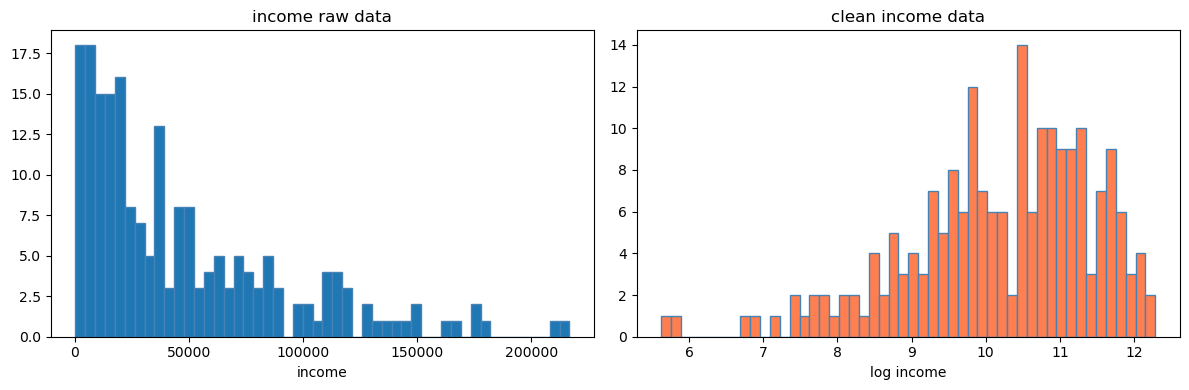

In [22]:
# Mathematical Transformations

income = np.random.exponential(50000, 1000)

fig, axes = plt.subplots(1,2, figsize = (12, 4))

axes[0].hist(df['income'], bins = 50, edgecolor = 'steelblue')
axes[0].set_xlabel('income')
axes[0].set_title('income raw data')

clean_income = np.log1p(df['income'])

axes[1].hist(clean_income, bins = 50, color = 'coral', edgecolor = 'steelblue')
axes[1].set_xlabel('log income')
axes[1].set_title('clean income data')

plt.tight_layout()
plt.show()

In [ ]:
df['']

In [23]:
# square root for skewed income column

sqrt = np.sqrt(df['income'])

print(sqrt)

0      153.177689
1      387.951120
2      256.587772
3      213.651884
4       92.093667
          ...    
195    146.555044
196    254.407688
197    337.201524
198    330.237231
199    275.096546
Name: income, Length: 200, dtype: float64


Encoding Categorical Variables

In [24]:
# One-Hot Encoding (for categories with NO order)

In [29]:
df_raw = pd.DataFrame({
    'city':   ['Lagos', 'Abuja', 'Kano', 'Lagos', 'Kano'],
    'income': [50000, 80000, 45000, 60000, 55000]
})


# Before Encoding
print(df_raw)

    city  income
0  Lagos   50000
1  Abuja   80000
2   Kano   45000
3  Lagos   60000
4   Kano   55000


In [30]:
# After Encoding

df_encoded = pd.get_dummies(df_raw, columns = ['city'], drop_first = True)

print(df_encoded)

   income  city_Kano  city_Lagos
0   50000      False        True
1   80000      False       False
2   45000       True       False
3   60000      False        True
4   55000       True       False


In [39]:
# Ordinal Encoding (for categories WITH order)

from sklearn.preprocessing import OrdinalEncoder

df_grade = pd.DataFrame({
    'grade':  ['B', 'A', 'F', 'C', 'D', 'A', 'B'],
    'score':  [75, 92, 35, 65, 55, 88, 78]
})

encoder = OrdinalEncoder(categories = [['F', 'D', 'C', 'B', 'A']])
df_grade['encoded_grade'] = encoder.fit_transform(df_grade[['grade']])

print(df_grade)

  grade  score  encoded_grade
0     B     75            3.0
1     A     92            4.0
2     F     35            0.0
3     C     65            2.0
4     D     55            1.0
5     A     88            4.0
6     B     78            3.0


In [43]:
# Binary Encoding (for two-category columns)

df['gender_encoded'] = (df['gender'] == 'M').astype(int)

# M = 1, F = 0

df['is-churned'] = (df['churned'] == 'Yes').astype(int)

df

,income,age,score,gender,city,churned,income_log,gender_encoded,is-churned
0,23463.404499,41,90,M,Kano,0,10.063240,1,0
1,150506.071546,28,82,M,Abuja,0,11.921765,1,0
2,65837.284677,25,76,M,Kano,1,11.094957,1,0
3,45647.127689,53,51,M,Abuja,1,10.728718,1,0
4,8481.243523,55,42,F,Kano,1,9.045730,0,0
...,...,...,...,...,...,...,...,...,...
195,21478.380791,41,45,F,Abuja,1,9.974849,0,0
196,64723.271486,29,97,M,Kano,0,11.077892,1,0
197,113704.867455,52,83,F,Kano,1,11.641370,0,0
198,109056.628470,50,84,M,Lagos,0,11.599632,1,0


Scaling

In [45]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

df_scale = pd.DataFrame({
    'age':    [25, 32, 45, 19, 55, 38],
    'income': [30000, 85000, 120000, 25000, 200000, 75000],
    'score':  [65, 80, 72, 55, 90, 78]
})

print('Before scaling')
print(df_scale.describe().round(2))

Before scaling
         age     income  score
count   6.00       6.00   6.00
mean   35.67   89166.67  73.33
std    13.20   64916.61  12.26
min    19.00   25000.00  55.00
25%    26.75   41250.00  66.75
50%    35.00   80000.00  75.00
75%    43.25  111250.00  79.50
max    55.00  200000.00  90.00


In [49]:
# StandardScaler — subtract mean, divide by std:
# Result: mean=0, std=1 for every column
# Use when: data is roughly normally distributed, no strong outliers

scaler = StandardScaler()

df_standard = pd.DataFrame(
    scaler.fit_transform(df_scale))
columns = df_scale.columns

print('\n After scaling')
print(df_standard.describe().round(2))


 After scaling
          0     1     2
count  6.00  6.00  6.00
mean   0.00 -0.00  0.00
std    1.10  1.10  1.10
min   -1.38 -1.08 -1.64
25%   -0.74 -0.81 -0.59
50%   -0.06 -0.15  0.15
75%    0.63  0.37  0.55
max    1.60  1.87  1.49


In [53]:
# Result: mean=0, std=1 for every column
# Use when: data is roughly normally distributed, no strong outliers

scaler = MinMaxScaler()

df_minmax = pd.DataFrame(
    scaler.fit_transform(df_scale))
columns = df_scale.columns

print('\n after minmax scaling')
print(df_minmax.describe().round(2))


 after minmax scaling
          0     1     2
count  6.00  6.00  6.00
mean   0.46  0.37  0.52
std    0.37  0.37  0.35
min    0.00  0.00  0.00
25%    0.22  0.09  0.34
50%    0.44  0.31  0.57
75%    0.67  0.49  0.70
max    1.00  1.00  1.00


In [57]:
# RobustScaler — uses median and IQR instead of mean and std:
# Result: median=0, IQR=1 for every column
# Use when: you have outliers — this is the safest default choice
# Because it uses median (not mean), outliers don't distort the scaling


scaler = RobustScaler()

df_robust = pd.DataFrame(
    scaler.fit_transform(df_scale))
columns = df_scale.columns

print('\n after robust scaling')
print(df_robust.describe().round(2))


 after robust scaling
          0     1     2
count  6.00  6.00  6.00
mean   0.04  0.13 -0.13
std    0.80  0.93  0.96
min   -0.97 -0.79 -1.57
25%   -0.50 -0.55 -0.65
50%    0.00  0.00  0.00
75%    0.50  0.45  0.35
max    1.21  1.71  1.18


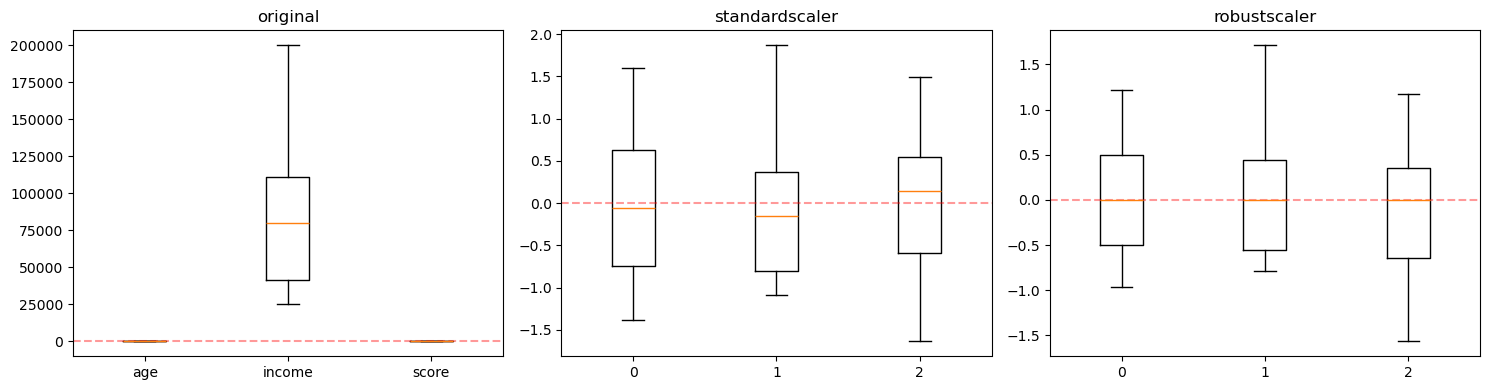

In [61]:
# Visual comparison of the three scalers

fig, axes = plt.subplots(1, 3, figsize = (15, 4))

for ax, (name, data) in zip(axes, [
    ('original', df_scale),
    ('standardscaler', df_standard),
    ('robustscaler', df_robust)
]):

    ax.boxplot([data[col] for col in data.columns], tick_labels = data.columns)
    ax.set_title(name)
    ax.axhline(y = 0, color = 'red', linestyle ='--', alpha = 0.4)

plt.tight_layout()
plt.show()

In [64]:
# Feature Selection

df_sel = pd.DataFrame({
    'age':            np.random.randint(18, 60, 300),
    'income':         np.random.exponential(50000, 300),
    'num_purchases':  np.random.randint(0, 100, 300),
    'total_spent':    np.random.exponential(3000, 300),
    'random_noise':   np.random.randn(300),   # completely useless feature
    'churned':        np.random.choice([0, 1], 300)
})

df_sel

,age,income,num_purchases,total_spent,random_noise,churned
0,27,16750.896451,89,1094.562634,0.298943,1
1,26,23577.939649,85,2230.168814,0.254967,0
2,32,70592.937561,30,3165.521489,0.295657,1
3,19,38789.690907,9,4535.341698,-0.276526,1
4,42,4032.507712,55,4372.349374,0.135207,0
...,...,...,...,...,...,...
295,47,28641.300011,24,1432.169431,-1.162273,0
296,40,8533.640828,78,4220.231070,-0.756091,1
297,36,147409.169043,89,3347.215618,0.867283,0
298,29,72803.426419,71,2272.743821,0.078120,1


In [70]:
correllation = df_sel.corr()['churned'].drop('churned')
correllation_abs = correllation.abs().sort_values(ascending = False)

print('\n correllation with target (churned):')
print(correllation_abs)


 correllation with target (churned):
num_purchases    0.089140
random_noise     0.084774
age              0.079669
total_spent      0.059767
income           0.024797
Name: churned, dtype: float64


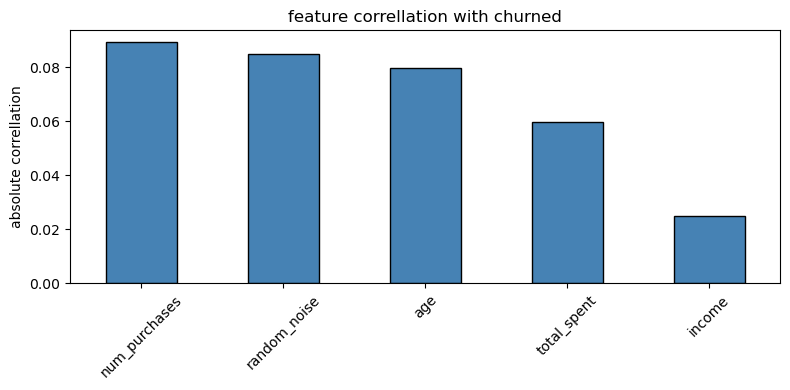

In [72]:


plt.figure(figsize = (8, 4))
correllation_abs.plot(kind = 'bar', color = 'steelblue', edgecolor = 'black')
plt.title('feature correllation with churned')
plt.ylabel('absolute correllation')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [73]:
# Drop features too weakly correlated with target

weak = correllation_abs[correllation_abs < 0.05].index

print(f'\nweak features to consider dropping {list(weak)}')
df_sel = df_sel.drop(columns = weak)


weak features to consider dropping ['income']
